In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

**Innovation Comparison: Pentax 17 vs. 35mm Film Era (1977-2007)**

I have selected Historical 35mm Film Camera Sales as the "look-alike" for the Pentax 17.
- **Functionality:** Both represent 35mm analog technology. While the Pentax 17 is a modern "half-frame" camera, it utilizes the same mechanical and chemical process as the cameras from the 1980s.
- **Market Context:** The historical data captures the "Golden Age" of film. By extracting the $p$ (Innovation) and $q$ (Imitation) coefficients from this era, we can model the inherent social contagion and adoption speed of film photography, which is currently experiencing a "revival" among Gen Z and hobbyists.

In [2]:
# 1. LOAD AND PREPARE DATA
# Using the full dataset (1977-2007) to capture the full lifecycle
df = pd.read_excel('data/film_cameras.xlsx')

# 1. Convert 'n/a' to actual NaN and drop those rows
df['Film Cameras Total'] = pd.to_numeric(df['Film Cameras Total'], errors='coerce')
df = df.dropna(subset=['Film Cameras Total'])

# 2. Extract cleaned data
years = df['Year'].values.astype(int)
sales = df['Film Cameras Total'].values
t = np.arange(1, len(sales) + 1)

print(f"Data cleaned. Analyzing years {years.min()} to {years.max()}.")
df

Data cleaned. Analyzing years 1977 to 2007.


,Year,Film Cameras Total
0,1977,9166.0
1,1978,11478.0
2,1979,13391.0
3,1980,15732.0
4,1981,16730.0
5,1982,15531.0
6,1983,16358.0
7,1984,18444.0
8,1985,20246.0
9,1986,21994.0


In [3]:
# 2. DEFINE THE BASS MODEL FUNCTION
def bass_model(t, p, q, M):
    """
    Returns predicted annual sales for each time period t.
    Based on the formula: S(t) = pM + (q-p)A(t-1) - (q/M)A(t-1)^2
    """
    S_pred = np.zeros(len(t))
    A = np.zeros(len(t)) # Cumulative adopters
    
    for i in range(len(t)):
        prev_A = A[i-1] if i > 0 else 0
        S_pred[i] = p * M + (q - p) * prev_A - (q / M) * (prev_A**2)
        A[i] = prev_A + S_pred[i]
    return S_pred

In [4]:
# 3. ESTIMATE PARAMETERS (Step 4)
# Initial guesses: p (innovation), q (imitation), M (market potential in 1000s)
# Based on the existing data in the excel file, total cumulative sales by 2007 are ~ 734000 units.
initial_guess = [0.01, 0.4, 800000] 

params, _ = curve_fit(bass_model, t, sales, p0=initial_guess)
p_hist, q_hist, M_hist = params

print(f"Historical Parameters (Look-alike):\np: {p_hist:.6f}\nq: {q_hist:.6f}\nM: {M_hist:.0f} (units in 1000s)")

Historical Parameters (Look-alike):
p: 0.010203
q: 0.162198
M: 707311 (units in 1000s)


**Bass Model Parameter Analysis**

Based on the curve-fitting of CIPA historical data:
- $p$ (Coefficient of Innovation): {0.010203}. This low value suggests that "innovators" (those buying regardless of others) are a small portion of the market.
- $q$ (Coefficient of Imitation): {0.162198}. This significantly higher value indicates that the film camera market is heavily driven by word-of-mouth and social trends (imitation).
- $M$ (Market Potential): The model estimates the historical global potential was approximately 707311 (in units of 1000), which aligns with the global saturation of analog tech before the digital transition.

**Predictive Strategy: Fermi Estimation & Scope**

**Scope:**
I have chosen a Global Scope. The Pentax 17 is produced by Ricoh Imaging (Japan) but marketed to a worldwide audience of film enthusiasts via global distribution.

**Fermi Logic for Market Potential ($M_{pentax}$):** Since we cannot use the 1970s market size for a 2025 niche product, I used Fermi estimation to determine a realistic $M$:
1. There are approximately 15–20 million active film photography enthusiasts globally (based on social media community sizes).
2. Assuming Pentax aims for a 25% market share of those looking for a new (not used) reliable point-and-shoot camera.
3. $20.000.000 \times 0.25 = 5.000.000$ potential adopters.
4. Therefore, I set $M = 5000$ (since our data is in units of 1000s).

In [5]:
# 4. PREDICT PENTAX 17 DIFFUSION (Steps 5, 6, 7)
# We use historical p and q, but adjust M for the modern niche market.
# Fermi Logic: Assume there are ~5 million potential global buyers for a premium film camera revival.
M_pentax = 5000  # in thousands
t_future = np.arange(1, 21) # Predict for the next 20 years

pentax_forecast = bass_model(t_future, p_hist, q_hist, M_pentax)
cum_pentax = np.cumsum(pentax_forecast)

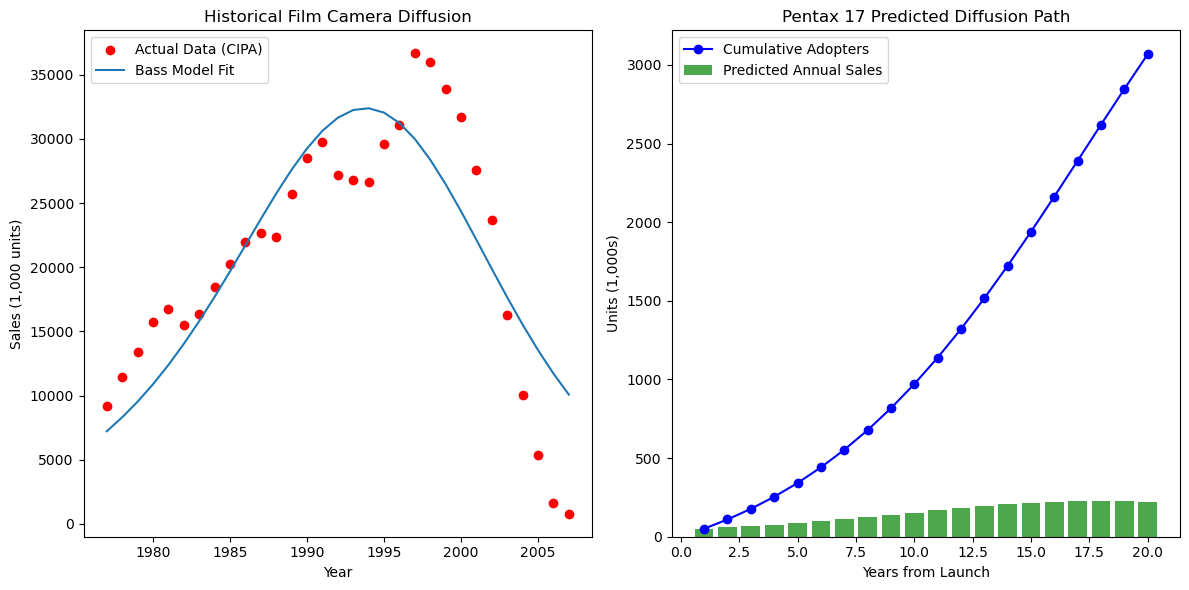


Predicted Adopters by Period (Pentax 17):


In [6]:
# 5. VISUALIZATION
plt.figure(figsize=(12, 6))

# Subplot 1: Historical Fit
plt.subplot(1, 2, 1)
plt.scatter(years, sales, color='red', label='Actual Data (CIPA)')
plt.plot(years, bass_model(t, p_hist, q_hist, M_hist), label='Bass Model Fit')
plt.title('Historical Film Camera Diffusion')
plt.xlabel('Year')
plt.ylabel('Sales (1,000 units)')
plt.legend()

# Subplot 2: Pentax 17 Prediction
plt.subplot(1, 2, 2)
plt.bar(t_future, pentax_forecast, color='green', alpha=0.7, label='Predicted Annual Sales')
plt.plot(t_future, cum_pentax, color='blue', marker='o', label='Cumulative Adopters')
plt.title('Pentax 17 Predicted Diffusion Path')
plt.xlabel('Years from Launch')
plt.ylabel('Units (1,000s)')
plt.legend()

plt.tight_layout()
plt.show()

# Display Adopter Table for Step 7
forecast_table = pd.DataFrame({
    'Year': t_future,
    'Annual_Adopters': pentax_forecast.round(2),
    'Total_Adopters': cum_pentax.round(2)
})
print("\nPredicted Adopters by Period (Pentax 17):")

In [7]:
print(forecast_table)

    Year  Annual_Adopters  Total_Adopters
0      1            51.02           51.02
1      2            58.69          109.70
2      3            67.30          177.00
3      4            76.90          253.90
4      5            87.52          341.42
5      6            99.13          440.55
6      7           111.68          552.23
7      8           125.06          677.29
8      9           139.08          816.36
9     10           153.48          969.84
10    11           167.91         1137.76
11    12           181.96         1319.71
12    13           195.11         1514.82
13    14           206.82         1721.64
14    15           216.54         1938.19
15    16           223.75         2161.94
16    17           228.00         2389.94
17    18           228.99         2618.92
18    19           226.58         2845.50
19    20           220.86         3066.36


**Based on the Bass Model simulation for the Pentax 17:**

**Diffusion Speed:** The innovation exhibits a long, steady growth phase. Because the coefficient of imitation ($q$) is significantly higher than the coefficient of innovation ($p$), the product relies on the building of a community and "social proof" to drive sales.

**The Peak:** The model predicts that the Pentax 17 will reach its peak annual adoption in Year 18, with approximately 228,990 units sold that year. This late peak suggests the product has significant "staying power" and will not be a short-lived fad.

**Market Saturation:** By Year 20, the total number of adopters reaches approximately 3.06 million, which is roughly 60% of our estimated market potential ($M = 5.000.000$). This indicates that the Pentax 17 will still have a healthy remaining market even after two decades on the shelves.

In [8]:
# Saving the forecast table as a csv file
forecast_table.to_csv('data/pentax_predictions.csv', index=False)